# Attention Map & Kernel Analysis
### `FCCAutoEncoderSRDoubleConvAttn` — `LAE_sr_double_conv_attn_01`

Six visualisations:
| # | File | What it shows |
|---|------|---------------|
| 1 | `01_spatial_weights` | Learned spatial aggregation kernels (all conv layers) |
| 2 | `02_transpose_kernels` | 22 depthwise upsampling kernels of `EquivariantTransposeConv` |
| 3 | `03_attn_params` | Per-block: `s4`/`s6` scales, position-bias weights, `lin_out` values |
| 4 | `04_attn_entropy` | Attention entropy / mean-received / self-attn spatial maps |
| 5 | `05_attn_block_matrices` | Selected (Nb×Nb) attention matrices from each HR attention block |
| 6 | `06_feature_norms` | ‖f4‖, ‖f6‖ norm maps at each pipeline stage |

In [1]:
%matplotlib inline
import json, sys, os, types
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── project root (works whether notebook is run from project root or visualization/)
ROOT = Path.cwd()
if ROOT.name == "visualization":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

from models.SR_double_conv_SRattn import FCCAutoEncoderSRDoubleConvAttn
from models.SR_grain_attn import LRBlockAttentionBlock

Project root: /data/home/umang/Materials/Reynolds-QSR-clean_e3nn


## Configuration
Edit the variables below before running the notebook.

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────
EXP_DIR    = ROOT / "experiments/IN718/LAE_sr_double_conv_attn_01"
RUN_DIR    = None        # None → latest timestamped sub-dir
CKPT_NAME  = "best_model.pt"

# ── data ──────────────────────────────────────────────────────────────────────
SPLIT      = "Test"      # "Train" | "Val" | "Test"
SAMPLE_IDX = 0           # which sample from the split

# ── compute ───────────────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ── output ────────────────────────────────────────────────────────────────────
SAVE_FIGS  = True        # also write PNGs to disk
SKIP_DATA  = False       # True → skip data-dependent cells (sections 4-6)

print(f"Device : {DEVICE}")
print(f"Exp dir: {EXP_DIR.name}")

Device : cuda
Exp dir: LAE_sr_double_conv_attn_01


## Helper functions

In [3]:
def load_config(exp_dir: Path) -> dict:
    with open(exp_dir / "config.json") as f:
        return json.load(f)

def find_latest_run(exp_dir: Path) -> Path:
    candidates = sorted([
        d for d in exp_dir.iterdir()
        if d.is_dir() and (d / "checkpoints").is_dir()
    ])
    if not candidates:
        raise FileNotFoundError(f"No run subdirs with checkpoints/ in {exp_dir}")
    return candidates[-1]

def build_model(cfg: dict, device) -> FCCAutoEncoderSRDoubleConvAttn:
    decoder_config = {
        "decoder_lookup_resolution":   int(cfg.get("decoder_lookup_resolution", 3)),
        "decoder_lookup_refine_steps": int(cfg.get("decoder_lookup_refine_steps", 0)),
        "decoder_w6":                  float(cfg.get("decoder_w6", 0.5)),
    }
    lr_shape_raw = cfg.get("lr_shape", None)
    lr_shape = tuple(int(x) for x in lr_shape_raw) if lr_shape_raw else None
    def _oi(key):
        v = cfg.get(key); return int(v) if v is not None else None
    return FCCAutoEncoderSRDoubleConvAttn(
        device=device,
        upsample_factor=int(cfg.get("scale", 4)),
        upsample_residual=bool(cfg.get("upsample_residual", False)),
        upsampler="conv",
        lr_shape=lr_shape,
        lr_conv_kernel_size=_oi("lr_conv_kernel_size"),
        lr_conv_kernel_size_1=_oi("lr_conv_kernel_size_1"),
        lr_conv_kernel_size_2=_oi("lr_conv_kernel_size_2"),
        decoder_backend=str(cfg.get("decoder_backend", "lookup")),
        decoder_config=decoder_config,
        num_hr_attn_blocks=int(cfg.get("hr_attn_num_blocks", 2)),
        hr_attn_num_channels=int(cfg.get("hr_attn_num_channels", 8)),
        hr_attn_block_size=int(cfg.get("hr_attn_block_size", 16)),
    ).to(device)

def load_checkpoint(model, ckpt_path: Path, device) -> int:
    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)
    if all(k.startswith("core.") for k in state):
        state = {k[5:]: v for k, v in state.items()}
    model.load_state_dict(state, strict=True)
    return int(ckpt.get("epoch", 0))

In [4]:
def _capturing_block_forward(self, feat, sh_block, H, W, block_h, block_w):
    """Replacement LRBlockAttentionBlock.forward that also saves attention weights."""
    B, N, C22 = feat.shape
    num_bh = H // block_h
    num_bw = W // block_w
    Nb  = block_h * block_w
    Bb  = B * num_bh * num_bw
    dtype = feat.dtype

    feat_blocks = (
        feat.reshape(B, num_bh, block_h, num_bw, block_w, C22)
            .permute(0, 1, 3, 2, 4, 5)
            .reshape(Bb, Nb, C22)
    )
    s4 = torch.exp(self.log_s4)
    s6 = torch.exp(self.log_s6)
    f4_n = F.normalize(feat_blocks[..., :9], dim=-1)
    f6_n = F.normalize(feat_blocks[..., 9:], dim=-1)
    scores_content = (
        s4 * torch.bmm(f4_n, f4_n.transpose(-2, -1))
        + s6 * torch.bmm(f6_n, f6_n.transpose(-2, -1))
    )
    pb     = self.pos_bias(sh_block)
    scores = scores_content + (pb + pb.T).unsqueeze(0)
    attn   = torch.softmax(scores.float(), dim=-1).to(dtype)

    self._attn_store.append({
        "block_idx":      self._attn_idx,
        "attn":           attn.detach().cpu().float(),
        "scores_content": scores_content.detach().cpu().float(),
        "num_bh": num_bh, "num_bw": num_bw,
        "block_h": block_h, "block_w": block_w,
    })
    return self._orig_forward(feat, sh_block, H, W, block_h, block_w)


class AttentionCapture:
    """Context manager: patches hr_attn_blocks to capture attention tensors."""
    def __init__(self, model):
        self.model = model
        self.data: List[Dict] = []

    def __enter__(self):
        self.data.clear()
        for i, blk in enumerate(self.model.hr_attn_blocks):
            blk._attn_store   = self.data
            blk._attn_idx     = i
            blk._orig_forward = blk.forward
            blk.forward       = types.MethodType(_capturing_block_forward, blk)
        return self

    def __exit__(self, *_):
        for blk in self.model.hr_attn_blocks:
            blk.forward = blk._orig_forward
            del blk._orig_forward, blk._attn_store, blk._attn_idx

In [5]:
class FeatureNormCapture:
    """Forward hooks on key submodules to record ||f4||, ||f6|| maps."""
    def __init__(self, model):
        self.model   = model
        self.stages: Dict[str, Dict] = {}
        self._handles: List = []

    def __enter__(self):
        self.stages.clear()
        capture = self

        def make_hook(name, shape_from_output=False):
            def hook(module, inp, output):
                if not isinstance(output, tuple):
                    return
                f4_out, f6_out = output[0], output[1]
                if shape_from_output and len(output) > 2:
                    H, W = output[2]
                elif len(inp) > 2 and isinstance(inp[2], (tuple, list)):
                    H, W = inp[2]
                else:
                    return
                f4 = f4_out.detach().cpu()
                f6 = f6_out.detach().cpu()
                if f4.dim() == 3:
                    f4, f6 = f4[0], f6[0]
                capture.stages[name] = {
                    "f4_norm": f4.norm(dim=-1).reshape(H, W).numpy(),
                    "f6_norm": f6.norm(dim=-1).reshape(H, W).numpy(),
                    "H": H, "W": W,
                }
                if name == "conv1 (LR k=5)" and "encoded (LR)" not in capture.stages:
                    f4_in = inp[0].detach().cpu()
                    f6_in = inp[1].detach().cpu()
                    if f4_in.dim() == 3:
                        f4_in, f6_in = f4_in[0], f6_in[0]
                    capture.stages["encoded (LR)"] = {
                        "f4_norm": f4_in.norm(dim=-1).reshape(H, W).numpy(),
                        "f6_norm": f6_in.norm(dim=-1).reshape(H, W).numpy(),
                        "H": H, "W": W,
                    }
            return hook

        for name, mod, sfo in [
            ("conv1 (LR k=5)",   self.model.conv_layer,    False),
            ("conv2 (LR k=9)",   self.model.conv_lr2,      False),
            ("upsample",         self.model.upsample_conv, True),
            ("conv_hr (HR k=3)", self.model.conv_hr,       False),
        ]:
            self._handles.append(mod.register_forward_hook(make_hook(name, sfo)))
        return self

    def __exit__(self, *_):
        for h in self._handles:
            h.remove()
        self._handles.clear()

## Plot functions

In [6]:
def _annotate_kernel(ax, w, fontsize=7):
    vmax = abs(w).max() if abs(w).max() > 0 else 1.0
    for (j, i), v in np.ndenumerate(w):
        color = "white" if abs(v) > 0.55 * vmax else "black"
        ax.text(i, j, f"{v:.3f}", ha="center", va="center",
                fontsize=fontsize, color=color)


def _savefig(fig, out_dir, name):
    if SAVE_FIGS and out_dir is not None:
        p = Path(out_dir) / name
        fig.savefig(p, dpi=200, bbox_inches="tight")
        print(f"  saved → {p.name}")


def plot_spatial_weights(model, out_dir=None):
    """Learned spatial aggregation kernels for all conv layers."""
    layers = [
        ("conv_layer\n(LR k=5)",    model.conv_layer.spatial_weights.detach().cpu().numpy()),
        ("conv_lr2\n(LR k=9)",      model.conv_lr2.spatial_weights.detach().cpu().numpy()),
        ("conv_hr\n(HR k=3)",       model.conv_hr.spatial_weights.detach().cpu().numpy()),
        ("upsample spatial\n(3×3)", model.upsample_conv.spatial_weights.detach().cpu().numpy()),
    ]
    fig, axes = plt.subplots(1, len(layers), figsize=(4.5 * len(layers), 5.5))
    for ax, (name, w) in zip(axes, layers):
        vmax = max(abs(w.min()), abs(w.max()), 1e-9)
        im = ax.imshow(w, cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
        ax.set_title(name, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        _annotate_kernel(ax, w, fontsize=6 if w.shape[0] > 5 else 7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlabel(f"shape: {w.shape[0]}×{w.shape[1]}", fontsize=8)
    fig.suptitle("Learned Spatial Aggregation Weights", fontsize=13, fontweight="bold")
    fig.tight_layout()
    _savefig(fig, out_dir, "01_spatial_weights.png")
    plt.show()


def plot_transpose_kernels(model, out_dir=None):
    """22 depthwise kernels of EquivariantTransposeConv."""
    kernels = model.upsample_conv.transpose_conv.weight.detach().cpu().squeeze(1).numpy()
    C, kH, kW = kernels.shape
    ncols, nrows = 11, (C + 10) // 11
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 2.1))
    axes_flat = axes.flatten()
    irrep_labels = [f"l=4 [{m}]" for m in range(9)] + [f"l=6 [{m}]" for m in range(13)]
    vabs = max(abs(kernels.min()), abs(kernels.max()), 1e-9)
    last_im = None
    for ax, k, lbl in zip(axes_flat, kernels, irrep_labels):
        last_im = ax.imshow(k, cmap="RdBu_r", vmin=-vabs, vmax=vabs, interpolation="nearest")
        ax.set_title(lbl, fontsize=7); ax.axis("off")
    for ax in axes_flat[C:]:
        ax.axis("off")
    if last_im is not None:
        fig.colorbar(last_im, ax=axes_flat.tolist(), fraction=0.008, pad=0.01,
                     label="Kernel weight")
    fig.suptitle(
        f"EquivariantTransposeConv Depthwise Kernels ({C} ch, {kH}×{kW})\n"
        f"First 9: l=4  |  Last 13: l=6",
        fontsize=11, fontweight="bold",
    )
    fig.tight_layout()
    _savefig(fig, out_dir, "02_transpose_kernels.png")
    plt.show()


def plot_attn_params(model, out_dir=None):
    """Learned parameters of each HR attention block."""
    blocks = list(model.hr_attn_blocks)
    n = len(blocks)
    fig, axes = plt.subplots(n, 4, figsize=(20, 4.5 * n))
    if n == 1: axes = axes[np.newaxis, :]
    sh_labels = ["SH 0e", "SH 2e[0]", "SH 2e[1]", "SH 2e[2]", "SH 2e[3]", "SH 2e[4]"]
    for i, blk in enumerate(blocks):
        s4, s6 = float(torch.exp(blk.log_s4)), float(torch.exp(blk.log_s6))
        ls4, ls6 = float(blk.log_s4), float(blk.log_s6)
        # Col 0: scale factors
        ax = axes[i, 0]
        bars = ax.bar(["s4 (l=4)", "s6 (l=6)"], [s4, s6], color=["#4C72B0", "#DD8452"])
        ax.set_title(f"Block {i}: Scales\nlog_s4={ls4:.3f}  log_s6={ls6:.3f}", fontsize=9)
        ax.set_ylabel("exp(log_s)"); ax.axhline(0, color="k", lw=0.5)
        for bar, v in zip(bars, [s4, s6]):
            ax.text(bar.get_x() + bar.get_width()/2, v*1.05,
                    f"{v:.4f}", ha="center", va="bottom", fontsize=9)
        # Col 1: position bias
        ax = axes[i, 1]
        pb_w = blk.pos_bias.weight.detach().cpu().numpy().flatten()
        pb_b = float(blk.pos_bias.bias.item())
        ax.bar(range(6), pb_w, color="#55A868"); ax.axhline(0, color="k", lw=0.5)
        ax.set_xticks(range(6))
        ax.set_xticklabels(sh_labels, fontsize=7, rotation=30, ha="right")
        ax.set_title(f"Block {i}: Position Bias Weights\n(bias={pb_b:.4f})", fontsize=9)
        ax.set_ylabel("Weight value")
        # Col 2: lin_out weights
        ax = axes[i, 2]
        lo_w = blk.lin_out.weight.detach().cpu().numpy().flatten()
        C_h = len(lo_w) // 2
        ax.bar(range(len(lo_w)), lo_w,
               color=["#4C72B0"]*C_h + ["#DD8452"]*(len(lo_w)-C_h))
        ax.axhline(0, color="k", lw=0.5)
        ax.axvline(C_h - 0.5, color="gray", lw=1.0, ls="--")
        ax.set_title(f"Block {i}: lin_out weights (len={len(lo_w)})\n"
                     f"Blue=l=4 ({C_h}), Orange=l=6 ({len(lo_w)-C_h})", fontsize=9)
        ax.set_xlabel("Index"); ax.set_ylabel("Weight")
        # Col 3: |lin_out| vs |lin_in|
        ax = axes[i, 3]
        li_w  = blk.lin_in.weight.detach().cpu().numpy().flatten()
        lo_nz, li_nz = np.abs(lo_w), np.abs(li_w)
        ax.bar(range(len(lo_nz)), lo_nz, color="#C44E52", label=f"lin_out (n={len(lo_nz)})")
        ax2 = ax.twinx()
        ax2.bar(np.arange(len(li_nz))+0.35, li_nz, width=0.35,
                color="#55A868", alpha=0.7, label=f"lin_in (n={len(li_nz)})")
        ax.set_title(f"Block {i}: |lin_out| vs |lin_in|", fontsize=9)
        ax.set_xlabel("Index"); ax.set_ylabel("|lin_out|", color="#C44E52")
        ax2.set_ylabel("|lin_in|", color="#55A868")
        lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
        lbls  = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
        ax.legend(lines, lbls, fontsize=7, loc="upper right")
    fig.suptitle("HR Attention Block Learned Parameters", fontsize=13, fontweight="bold")
    fig.tight_layout()
    _savefig(fig, out_dir, "03_attn_params.png")
    plt.show()

In [7]:
def _to_spatial(x, num_bh, num_bw, block_h, block_w):
    Hr, Wr = num_bh * block_h, num_bw * block_w
    return (x.reshape(num_bh, num_bw, block_h, block_w)
              .permute(0, 2, 1, 3).reshape(Hr, Wr).numpy())

def _attn_spatial_maps(entry):
    attn = entry["attn"]
    kw   = {k: entry[k] for k in ("num_bh","num_bw","block_h","block_w")}
    entropy   = -(attn * (attn + 1e-9).log()).sum(-1)
    mean_recv = attn.mean(1)
    self_attn = torch.diagonal(attn, dim1=1, dim2=2)
    return (_to_spatial(entropy, **kw),
            _to_spatial(mean_recv, **kw),
            _to_spatial(self_attn, **kw))


def plot_attn_entropy(attn_data, ipf_rgb=None, out_dir=None):
    """Attention entropy / mean-received / self-attn spatial maps."""
    n  = len(attn_data)
    nc = 4 if ipf_rgb is not None else 3
    fig, axes = plt.subplots(n, nc, figsize=(5.2 * nc, 4.5 * n))
    if n == 1: axes = axes[np.newaxis, :]
    for row, entry in enumerate(attn_data):
        ent_map, recv_map, self_map = _attn_spatial_maps(entry)
        bidx = entry["block_idx"]
        for col, (title, m, cmap) in enumerate([
            ("Attention Entropy\n[nats/pixel]",             ent_map,  "viridis"),
            ("Mean Attention Received\n[col-avg]",          recv_map, "hot"),
            ("Self-Attention Weight\n[diag(A)]",            self_map, "plasma"),
        ]):
            ax = axes[row, col]
            im = ax.imshow(m, cmap=cmap, interpolation="nearest")
            ax.set_title(f"Block {bidx}: {title}", fontsize=9)
            ax.axis("off"); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85)
        if ipf_rgb is not None:
            ax = axes[row, 3]
            ax.imshow(ipf_rgb)
            ent_norm = (ent_map - ent_map.min()) / (ent_map.max() - ent_map.min() + 1e-9)
            ax.imshow(ent_norm, cmap="hot", alpha=0.45, interpolation="nearest")
            ax.set_title(f"Block {bidx}: IPF-Z + entropy overlay", fontsize=9)
            ax.axis("off")
    fig.suptitle("HR Attention Block — Spatial Analysis", fontsize=13, fontweight="bold")
    fig.tight_layout()
    _savefig(fig, out_dir, "04_attn_entropy.png")
    plt.show()


def plot_attn_block_matrices(attn_data, out_dir=None, n_samples=6):
    """(Nb×Nb) attention matrices for a handful of representative spatial blocks."""
    n_blocks = len(attn_data)
    ncols    = n_samples + 1
    fig, axes = plt.subplots(n_blocks, ncols, figsize=(2.8 * ncols, 3.2 * n_blocks))
    if n_blocks == 1: axes = axes[np.newaxis, :]
    for row, entry in enumerate(attn_data):
        attn  = entry["attn"]
        Bb    = attn.shape[0]
        bidx  = entry["block_idx"]
        num_bh, num_bw = entry["num_bh"], entry["num_bw"]
        center = num_bh // 2 * num_bw + num_bw // 2
        candidates = sorted(set([
            0, num_bw - 1, (num_bh-1)*num_bw, Bb-1, center, Bb//3
        ]))[:n_samples]
        for col, sp_idx in enumerate(candidates):
            ax  = axes[row, col]
            mat = attn[sp_idx].numpy()
            im  = ax.imshow(mat, cmap="hot", vmin=0.0, aspect="equal",
                            interpolation="nearest")
            ax.set_title(f"B{bidx} [{sp_idx//num_bw},{sp_idx%num_bw}]", fontsize=7)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.7)
        ax   = axes[row, -1]
        mean_mat = attn.mean(0).numpy()
        im   = ax.imshow(mean_mat, cmap="hot", vmin=0.0, aspect="equal",
                         interpolation="nearest")
        ax.set_title(f"B{bidx} mean\n(all {Bb} blocks)", fontsize=7)
        ax.axis("off"); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.7)
    fig.suptitle(
        f"HR Attention Matrices — {n_samples} sampled + mean  "
        f"(each axis = Nb pixels within one HR block)",
        fontsize=11, fontweight="bold",
    )
    fig.tight_layout()
    _savefig(fig, out_dir, "05_attn_block_matrices.png")
    plt.show()


def plot_feature_norms(stages, out_dir=None):
    """||f4||, ||f6|| norm maps at each pipeline stage."""
    order = ["encoded (LR)", "conv1 (LR k=5)", "conv2 (LR k=9)",
             "upsample", "conv_hr (HR k=3)"]
    keys = [k for k in order if k in stages] +            [k for k in stages if k not in order]
    n = len(keys)
    if n == 0: return
    fig, axes = plt.subplots(n, 2, figsize=(11, 3.5 * n))
    if n == 1: axes = axes[np.newaxis, :]
    for row, name in enumerate(keys):
        info = stages[name]
        for col, (feat, lbl, cmap) in enumerate([
            (info["f4_norm"], "‖f4‖  (l=4,  9 comps)", "plasma"),
            (info["f6_norm"], "‖f6‖  (l=6, 13 comps)", "viridis"),
        ]):
            ax = axes[row, col]
            im = ax.imshow(feat, cmap=cmap, interpolation="nearest")
            ax.set_title(f"{name}  [{info['H']}×{info['W']}]: {lbl}", fontsize=9)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85).ax.tick_params(labelsize=7)
    fig.suptitle("Feature Norm Maps at Each Pipeline Stage", fontsize=13, fontweight="bold")
    fig.tight_layout()
    _savefig(fig, out_dir, "06_feature_norms.png")
    plt.show()

---
## 1. Setup — build & load model

In [8]:
exp_dir   = EXP_DIR.resolve()
run_dir   = Path(RUN_DIR).resolve() if RUN_DIR else find_latest_run(exp_dir)
ckpt_path = run_dir / "checkpoints" / CKPT_NAME
out_dir   = run_dir / "attention_analysis"
out_dir.mkdir(parents=True, exist_ok=True)
device    = torch.device(DEVICE)

cfg   = load_config(exp_dir)
model = build_model(cfg, device)
model.eval()
epoch = load_checkpoint(model, ckpt_path, device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Run dir            : {run_dir.name}")
print(f"Checkpoint epoch   : {epoch}")
print(f"Trainable params   : {n_params:,}")
print(f"HR attn blocks     : {len(model.hr_attn_blocks)}")
print(f"Output dir         : {out_dir}")

Run dir            : 2026-02-27_11-36-07
Checkpoint epoch   : 52
Trainable params   : 9,990
HR attn blocks     : 2
Output dir         : /data/home/umang/Materials/Reynolds-QSR-clean_e3nn/experiments/IN718/LAE_sr_double_conv_attn_01/2026-02-27_11-36-07/attention_analysis


---
## 2. Static Analysis: Kernels & Weights

### 2a. Spatial aggregation kernels (all conv layers)

  saved → 01_spatial_weights.png


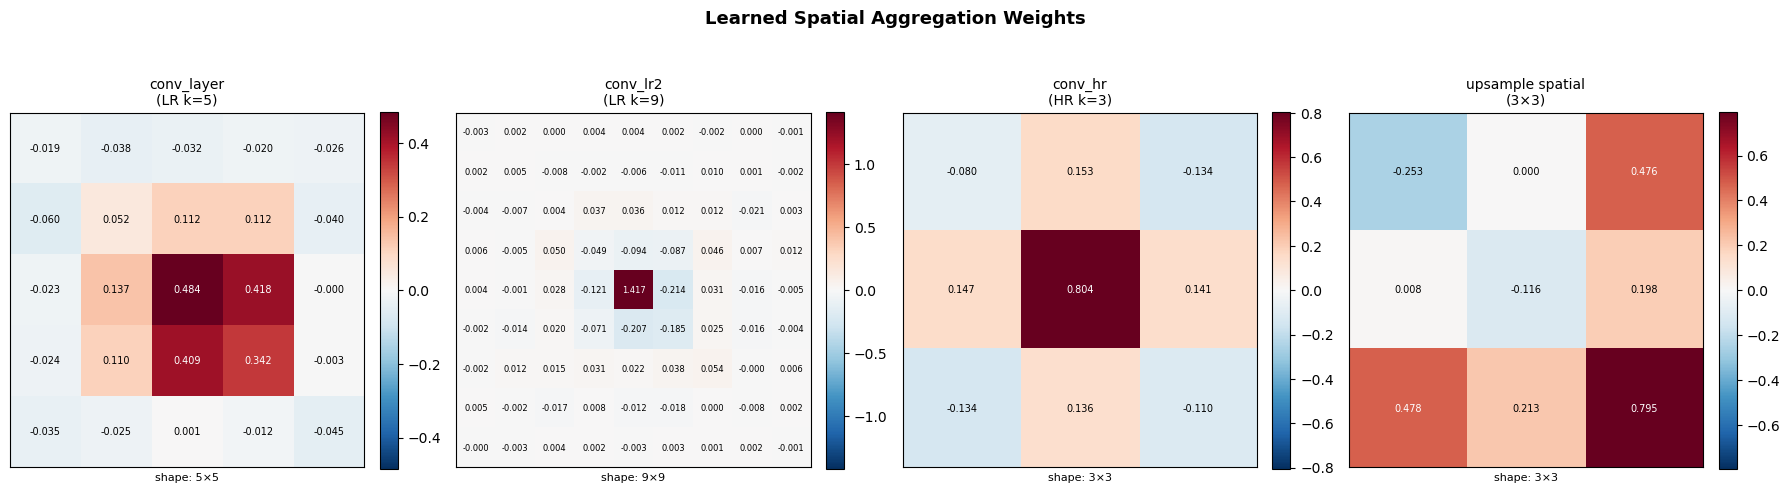

In [9]:
plot_spatial_weights(model, out_dir if SAVE_FIGS else None)

### 2b. Depthwise transpose conv kernels (22 channels)

/tmp/ipykernel_1024346/981748069.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved → 02_transpose_kernels.png


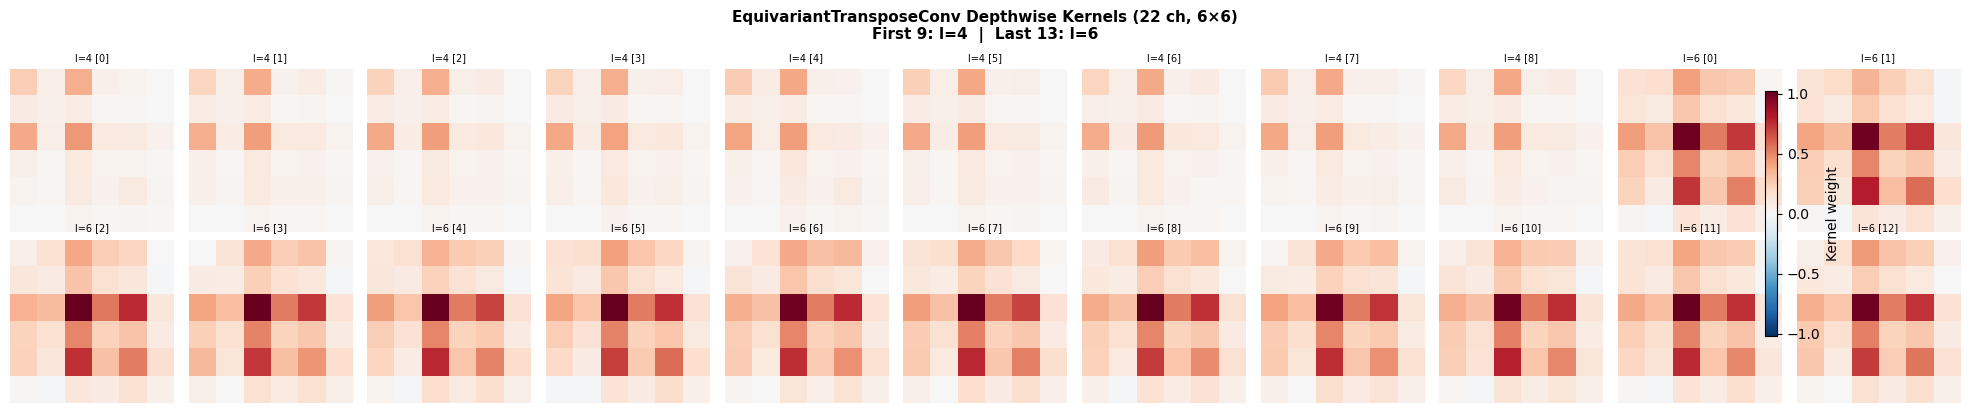

In [10]:
plot_transpose_kernels(model, out_dir if SAVE_FIGS else None)

### 2c. HR attention block parameters

  saved → 03_attn_params.png


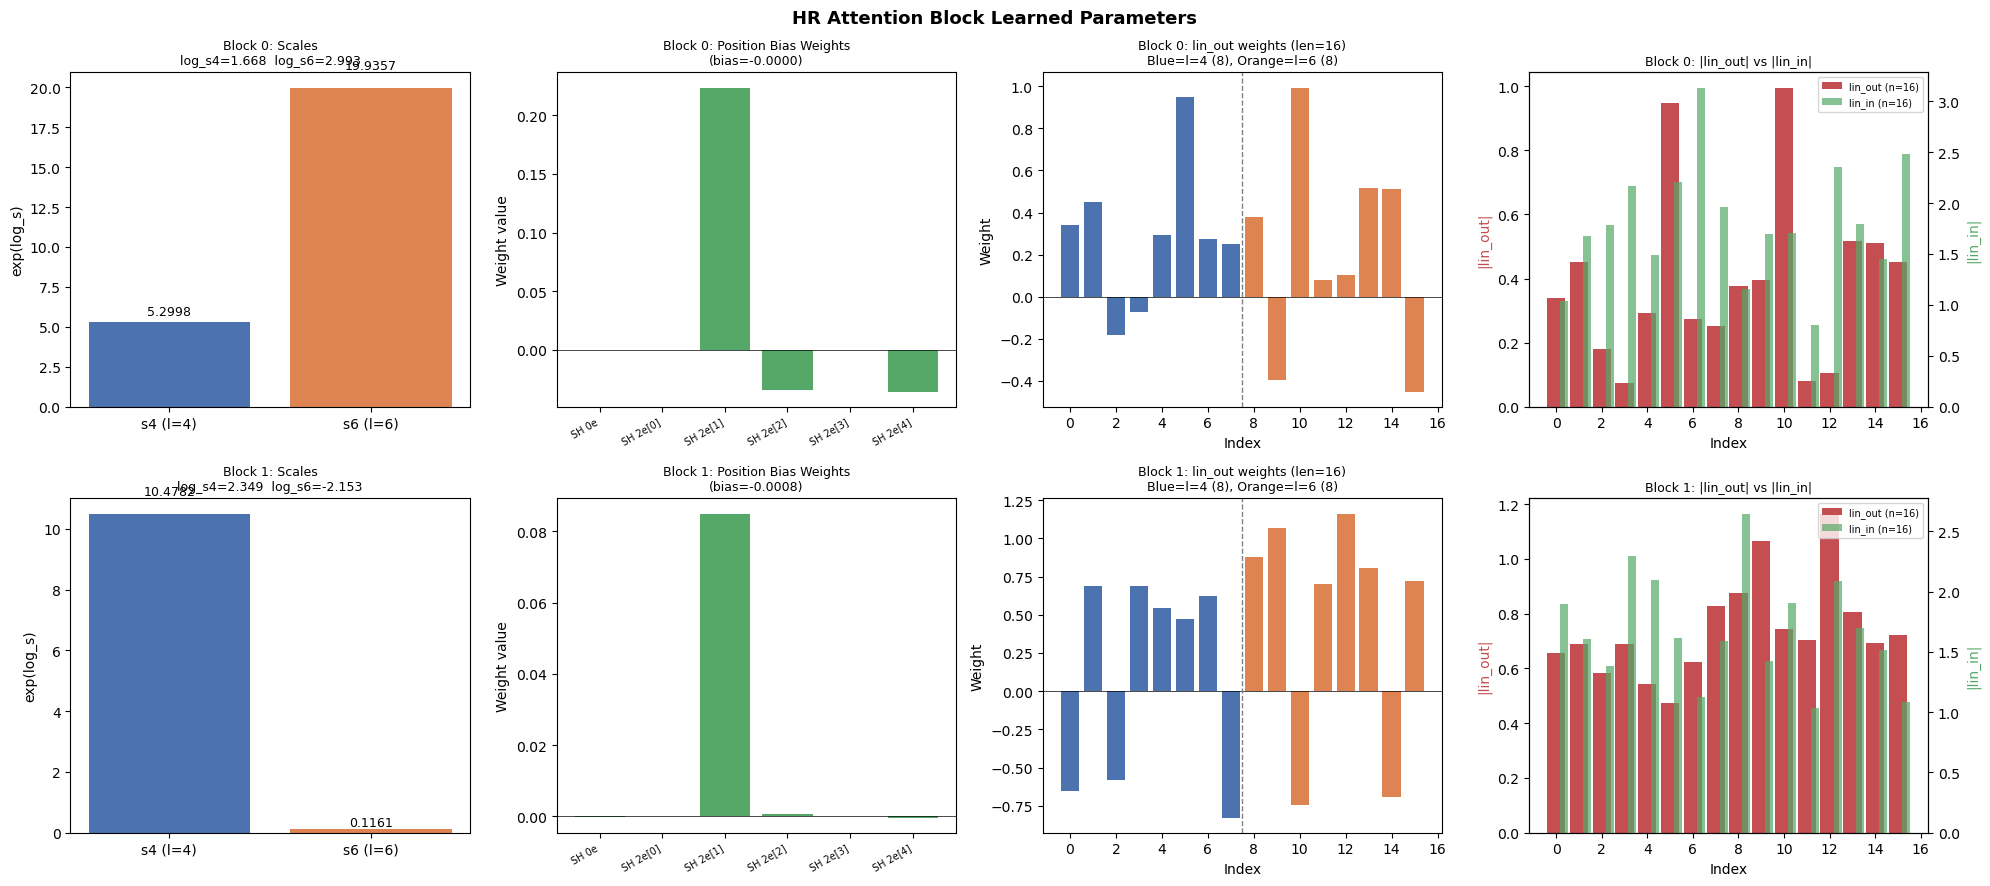

In [11]:
plot_attn_params(model, out_dir if SAVE_FIGS else None)

---
## 3. Load Data Sample

In [12]:
if SKIP_DATA:
    print("SKIP_DATA=True — skipping sections 3-6. Set SKIP_DATA=False to run them.")
else:
    from training.data_loading import build_dataloader

    loader = build_dataloader(
        dataset_root=cfg["dataset_root"],
        split=SPLIT,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        preload=False,
        preload_torch=False,
        pin_memory=False,
    )

    lr_flat = hr_flat = lr_shape = hr_shape = None
    for idx, (lr_batch, hr_batch) in enumerate(loader):
        if idx == SAMPLE_IDX:
            lr_b = lr_batch[0]; hr_b = hr_batch[0]
            H_lr, W_lr = int(lr_b.shape[1]), int(lr_b.shape[2])
            H_hr, W_hr = int(hr_b.shape[1]), int(hr_b.shape[2])
            lr_shape = (H_lr, W_lr); hr_shape = (H_hr, W_hr)
            lr_flat  = lr_b.permute(1, 2, 0).reshape(-1, 4).to(device)
            lr_flat  = lr_flat / lr_flat.norm(dim=1, keepdim=True).clamp_min(1e-12)
            hr_flat  = hr_b.permute(1, 2, 0).reshape(-1, 4)
            print(f"Sample {SAMPLE_IDX} ({SPLIT})  LR: {lr_shape}   HR: {hr_shape}")
            break
    if lr_flat is None:
        raise ValueError(f"sample_idx={SAMPLE_IDX} out of range for split '{SPLIT}'")


Sample 0 (Test)  LR: (32, 32)   HR: (128, 128)


---
## 4. Forward Pass with Captures

In [13]:
if not SKIP_DATA:
    feat_capture = FeatureNormCapture(model)
    attn_capture = AttentionCapture(model)

    with torch.no_grad(), feat_capture, attn_capture:
        q_sr = model.forward_sr(lr_flat, lr_shape=lr_shape)

    print(f"Attention entries : {len(attn_capture.data)} ({len(model.hr_attn_blocks)} block(s))")
    print(f"Feature-norm stages: {list(feat_capture.stages.keys())}")

    # IPF-Z render (for entropy overlay)
    ipf_rgb = None
    try:
        from orix.quaternion.symmetry import Oh
        from visualization.ipf_render import render_ipf_rgb
        q_hr_np = hr_flat.reshape(H_hr, W_hr, 4).numpy()
        ipf_rgb = render_ipf_rgb(q_hr_np, Oh, ref_dir="Z")
        print("IPF-Z render: OK")
    except Exception as exc:
        print(f"IPF render skipped: {exc}")


Attention entries : 2 (2 block(s))
Feature-norm stages: ['conv1 (LR k=5)', 'encoded (LR)', 'conv2 (LR k=9)', 'upsample', 'conv_hr (HR k=3)']
IPF-Z render: OK


---
## 5. Attention Maps

### 5a. Spatial maps: entropy, mean received, self-attention

  saved → 04_attn_entropy.png


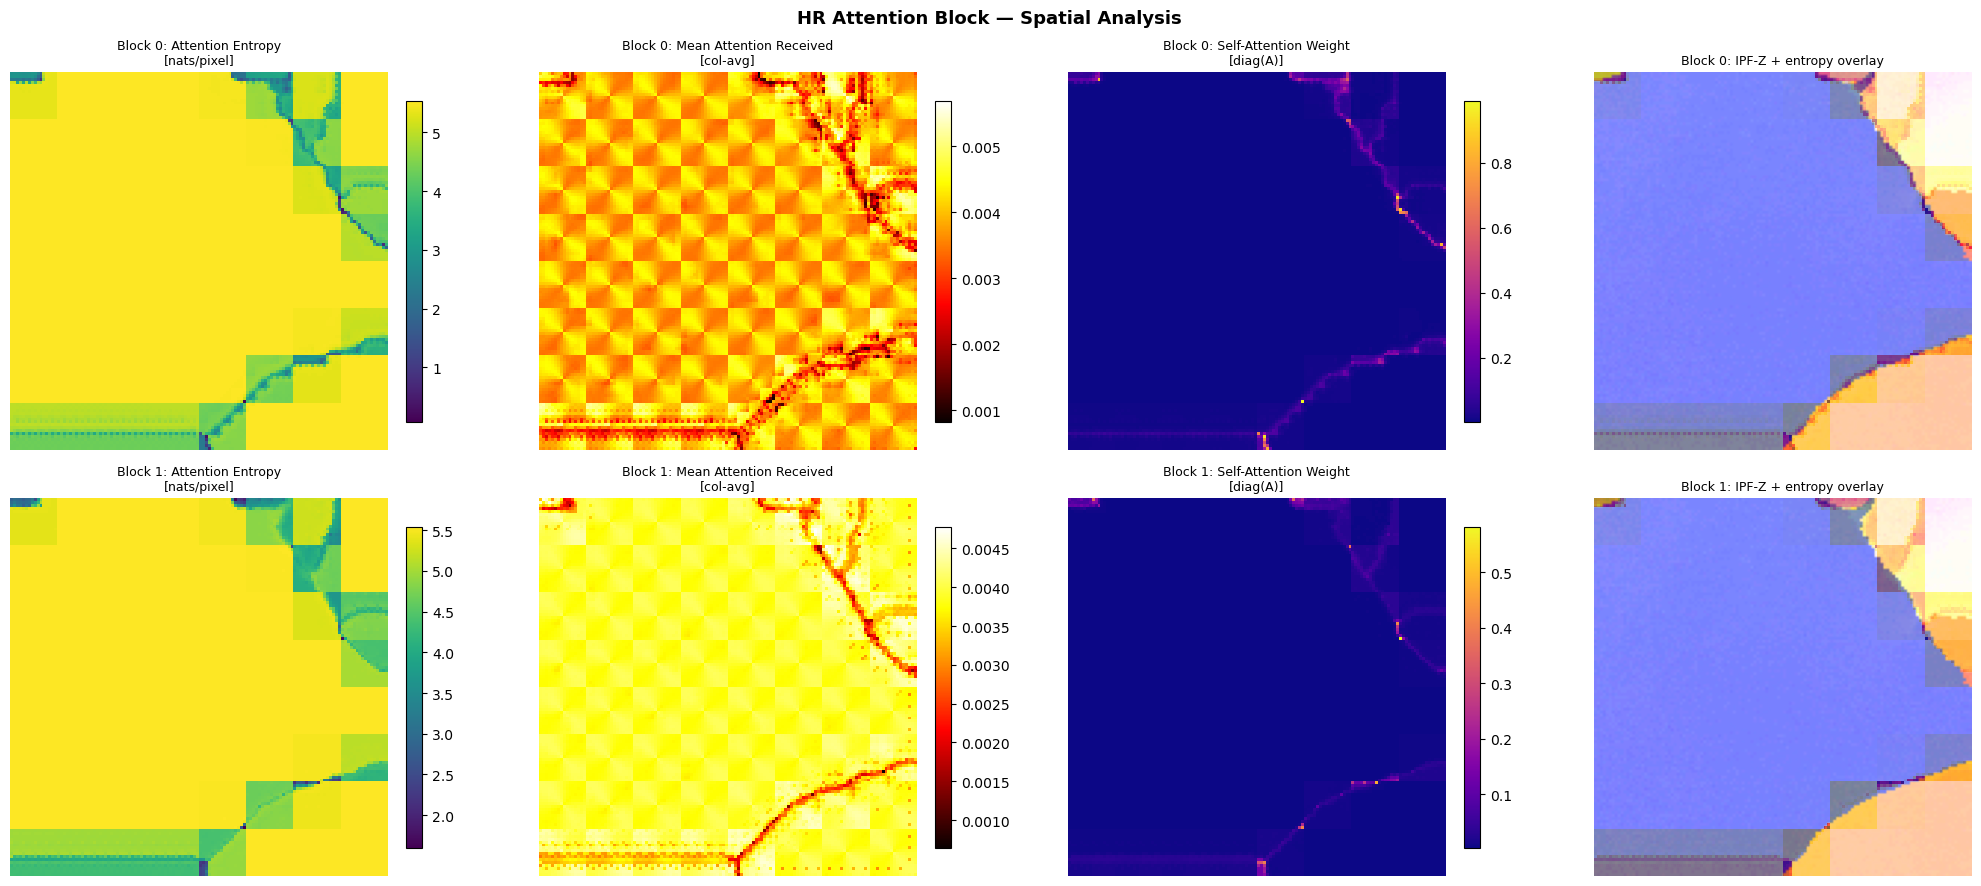

In [14]:
if not SKIP_DATA:
    plot_attn_entropy(attn_capture.data, ipf_rgb,
                      out_dir if SAVE_FIGS else None)

### 5b. Individual block attention matrices

  saved → 05_attn_block_matrices.png


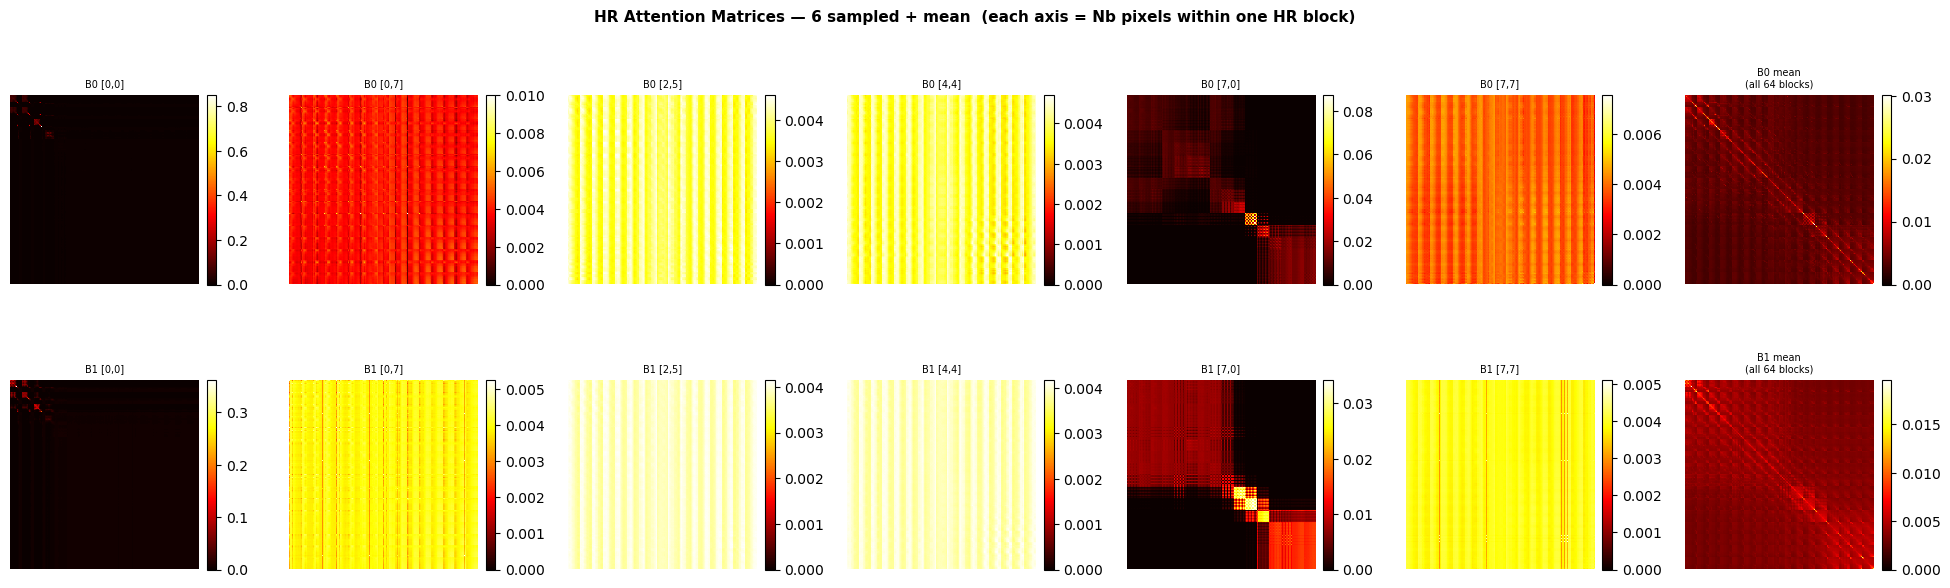

In [15]:
if not SKIP_DATA:
    plot_attn_block_matrices(attn_capture.data,
                             out_dir if SAVE_FIGS else None)

---
## 6. Feature Norms at Each Stage

  saved → 06_feature_norms.png


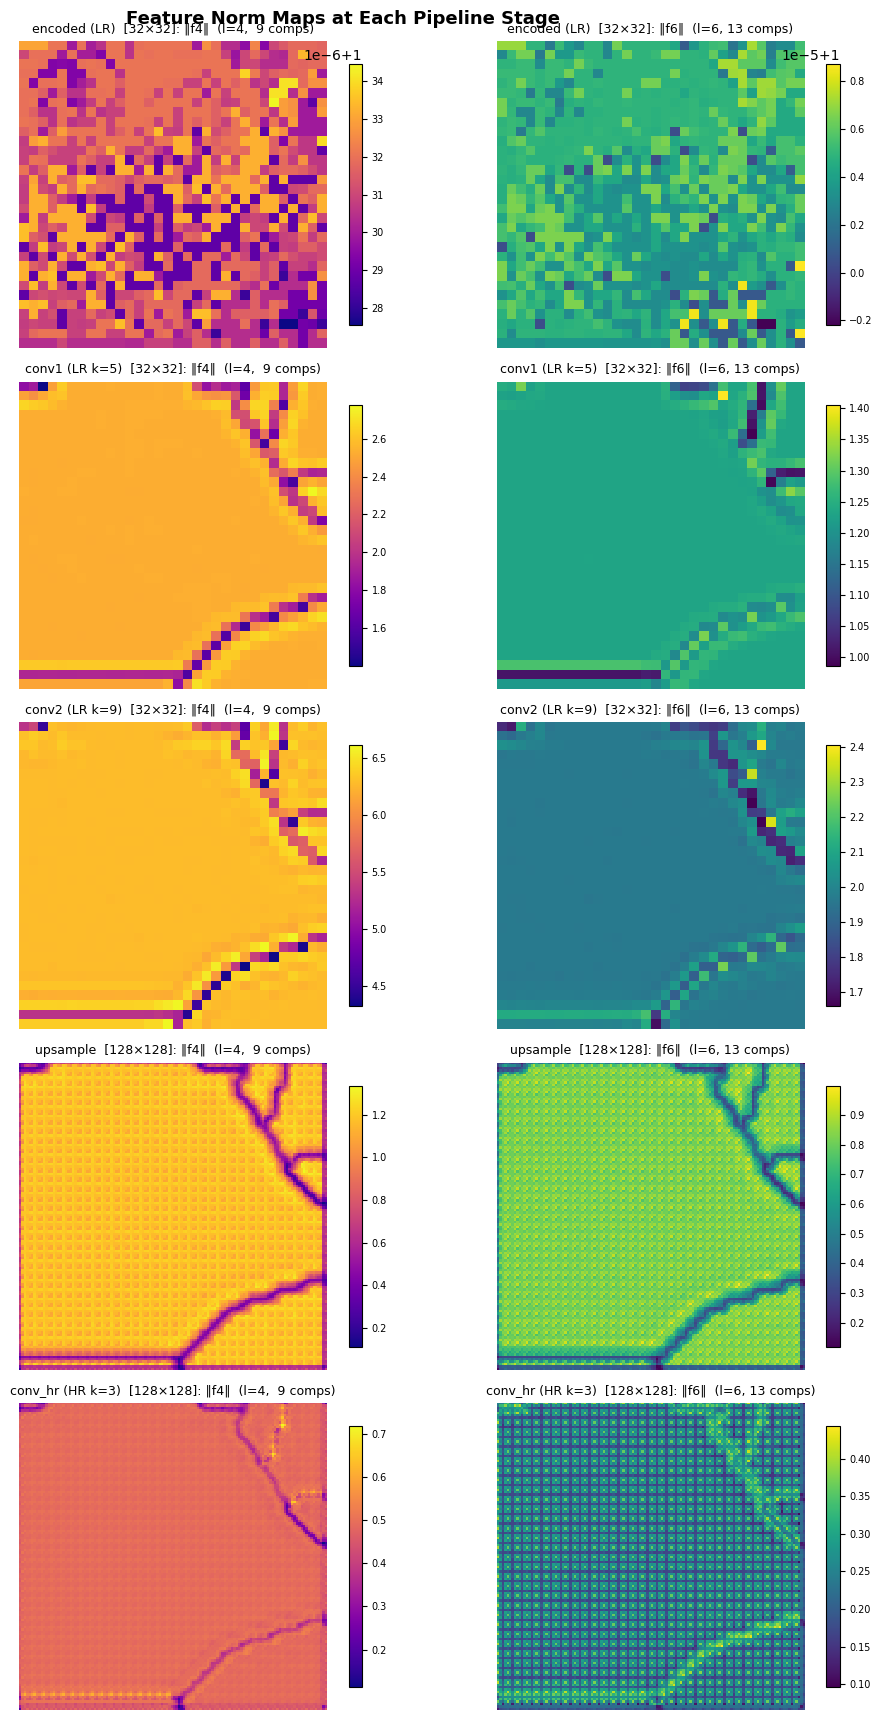

: 

In [ ]:
if not SKIP_DATA:
    plot_feature_norms(feat_capture.stages,
                       out_dir if SAVE_FIGS else None)